In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
#Importing data set
data = pd.read_csv("D:/Excel/Data_set1.csv")
data.head(2)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591


## Data Cleaning


In [3]:
data.shape

(9551, 21)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [5]:
data.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [6]:
data.isnull().sum().sum()

9

In [7]:
#Print the column with null values and number of nulll values
df = data.isnull().sum()
df = df[df  > 0]
df

Cuisines    9
dtype: int64

In [8]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9546    False
9547    False
9548    False
9549    False
9550    False
Length: 9551, dtype: bool

In [9]:
data.shape

(9551, 21)

In [10]:
data.drop_duplicates()
data.shape

(9551, 21)

### Task: Determine the top three most common cuisines in the dataset

In [11]:
most_comman_cuisines = data['Cuisines'].value_counts()
most_comman_cuisines.head(3)

Cuisines
North Indian             936
North Indian, Chinese    511
Chinese                  354
Name: count, dtype: int64

In [12]:
cuisines_list = data['Cuisines'].str.split(',')
cuisines = [cuisine.strip() for sublist in cuisines_list if isinstance(sublist, list) for cuisine in sublist]

cuisine_counts = Counter(cuisines)
print("Most 3 top common cuisines are: ", cuisine_counts.most_common(3))

Most 3 top common cuisines are:  [('North Indian', 3960), ('Chinese', 2735), ('Fast Food', 1986)]


###  Calculate the percentage of restaurants that serve each of the top cuisines

In [13]:
data['Cuisines'] = data['Cuisines'].fillna('')
total_restorent = len(cuisines)
top_cuisines = ['North Indian', 'Chinese', 'Fast Food']
percentage_per_cuisine = {}

for cuisine in top_cuisines:
    num_restorents_servinng_cuine = data[data['Cuisines'].str.contains(cuisine)].shape[0]
    percentage = (num_restorents_servinng_cuine/total_restorent) * 100
    percentage_per_cuisine[cuisine] = percentage

print("Percentage of top 3 restaurants:  ")
for cuisine, percentage in percentage_per_cuisine.items():
    print(f"{cuisine}  :  {percentage:.2f}%")

Percentage of top 3 restaurants:  
North Indian  :  20.09%
Chinese  :  13.87%
Fast Food  :  10.08%


## Identify the city with the highest number of restaurants in the dataset.

In [14]:
max_restaurants = data["City"].value_counts()
print("City with the highest number of restaurants:  ")
print(max_restaurants.head())

City with the highest number of restaurants:  
City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
Name: count, dtype: int64


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9551 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

## Calculate the average rating for restaurants in each city

In [16]:
avg_rating_for_restaurants = data.groupby('City')['Aggregate rating'].mean()
print("The average rating for Restaurants in each city: ")
print(avg_rating_for_restaurants)

The average rating for Restaurants in each city: 
City
??stanbul          4.292857
Abu Dhabi          4.300000
Agra               3.965000
Ahmedabad          4.161905
Albany             3.555000
                     ...   
Waterloo           3.650000
Weirton            3.900000
Wellington City    4.250000
Winchester Bay     3.200000
Yorkton            3.300000
Name: Aggregate rating, Length: 141, dtype: float64


## Determine the city with the highest average rating.

In [17]:
city_with_highest_avg_rating = avg_rating_for_restaurants.idxmax()
highest_avg_rating = avg_rating_for_restaurants.max()

print("City with the highest average rating:", city_with_highest_avg_rating)
print("Average rating:", highest_avg_rating)

City with the highest average rating: Inner City
Average rating: 4.9


## Create a histogram or bar chart to visualize the distribution of price ranges among the restaurants

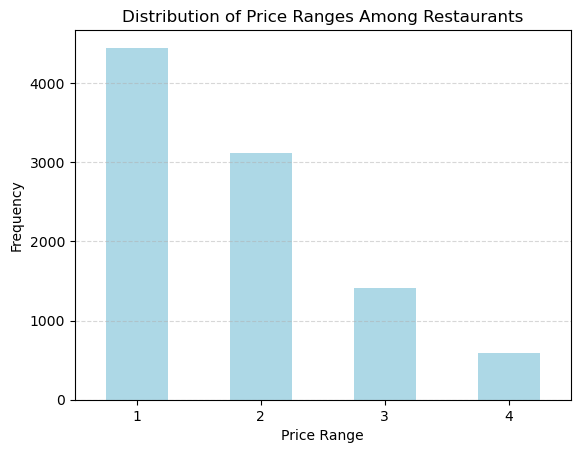

In [18]:
data['Price range'].value_counts().sort_index().plot(kind='bar', color='lightblue')
plt.title('Distribution of Price Ranges Among Restaurants')
plt.xlabel('Price Range')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Create the percentage of restaurants in each price range category

In [19]:
price_counts = Counter(data['Price range'])
print(price_counts)

Counter({1: 4444, 2: 3113, 3: 1408, 4: 586})


In [20]:
categories = list(price_counts.keys())
counts = list(price_counts.values())

print(categories, counts)

[3, 4, 2, 1] [1408, 586, 3113, 4444]


In [21]:
price_counts = data['Price range'].value_counts()

In [22]:
price_counts.index.tolist()
total_restaurent = len(data)

print("The percentage of restaurants in each price range category: ")
for price, count in price_counts.items():
    print(f"{price} {(count/total_restaurent) * 100:.2f}%")

The percentage of restaurants in each price range category: 
1 46.53%
2 32.59%
3 14.74%
4 6.14%


## Determine the percentage of resturants that offer online delivery

In [23]:
counts_online = data['Has Online delivery'].value_counts()

In [24]:
total_resturarnts = len(data)
for val, number in counts_online.items():
    if val == 'Yes': print(f"The percentage of resturants that offer online delivery:  {(number/total_resturarnts) * 100:.2f}%")

The percentage of resturants that offer online delivery:  25.66%


## Compare the average ratings of restaurants with and without online delivery

In [25]:
avg_with_online = data.groupby('Has Online delivery')['Aggregate rating'].mean()
print("The average ratings of restaurants with and without online delivery", avg_with_online)

The average ratings of restaurants with and without online delivery Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


The average ratings of restaurants with online delivery are higher compared to those without online delivery. 

## Level -2

### Restaurant Ratings

### Analyze the distribution of aggregate ratings and determine the most common rating range.

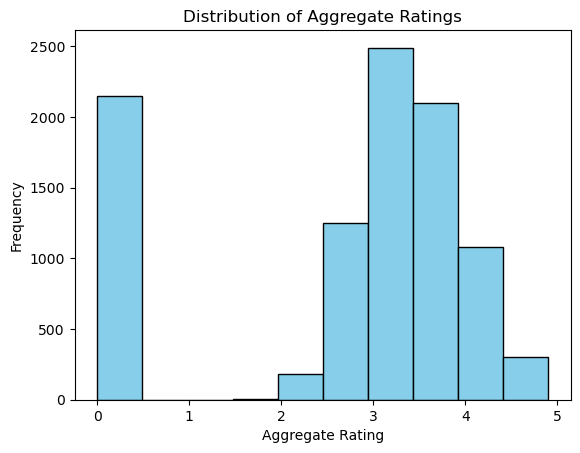

In [26]:
ratings = data["Aggregate rating"]

plt.hist(ratings, bins=10, color='skyblue', edgecolor='black')

plt.xlabel('Aggregate Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Aggregate Ratings')
plt.show()

In [27]:
most_common_range = ratings.mode()
numbers_of_ratings = data["Aggregate rating"].value_counts().max()
print("Most common rating range:", most_common_range[0], "It contains : ",  numbers_of_ratings , "numbers ")

Most common rating range: 0.0 It contains :  2148 numbers 


## Calculate the average number of votes receied by restaurants

In [28]:
average_votes = data['Votes'].mean()
print(f" The average number of votes received  by Restaurant: {average_votes:.2f}")

 The average number of votes received  by Restaurant: 156.91


## Cuisine Combination

### Identify the most common combinations of cuisines in the dataset

In [29]:
print("Most common combinatioons of cuisines: ")
data['Cuisines'].value_counts().head(5)

Most common combinatioons of cuisines: 


Cuisines
North Indian             936
North Indian, Chinese    511
Chinese                  354
Fast Food                354
North Indian, Mughlai    334
Name: count, dtype: int64

## Determine if certain cuisine combinations tend to have higher ratings

In [30]:
data.groupby('Cuisines')['Aggregate rating'].max().sort_values(ascending = False).head(10)

Cuisines
Japanese                        4.9
Indian, North Indian            4.9
Brazilian, Bar Food             4.9
Italian, Deli                   4.9
Italian, Bakery, Continental    4.9
British                         4.9
International                   4.9
Burger                          4.9
Burger, Bar Food, Steak         4.9
American, Burger, Grill         4.9
Name: Aggregate rating, dtype: float64

## Identify if there are any restaurants chains present in the dataset

In [31]:
restaurants_counts = data['Restaurant Name'].value_counts()
restaurant_chain= restaurants_counts[restaurants_counts > 1]
restaurant_chain.nunique()

29

There are 29 restaurants chains present in the dataset

In [32]:
restaurant_chain

Restaurant Name
Cafe Coffee Day       83
Domino's Pizza        79
Subway                63
Green Chick Chop      51
McDonald's            48
                      ..
Town Hall              2
Halki Aanch            2
Snack Junction         2
Delhi Biryani Hut      2
Beliram Degchiwala     2
Name: count, Length: 734, dtype: int64

### Analyze the ratings and popularity of different restaurant chains.

In [33]:
data_chain=data[data['Restaurant Name'].isin(restaurant_chain.index)]
chain_ratings=data_chain.groupby('Restaurant Name')['Aggregate rating'].mean().sort_values(ascending=False)
print("Average Ratings of Restaurant Chains:")
print(chain_ratings)

Average Ratings of Restaurant Chains:
Restaurant Name
Talaga Sampireun                   4.900
AB's Absolute Barbecues            4.850
Silantro Fil-Mex                   4.850
AB's - Absolute Barbecues          4.825
Naturals Ice Cream                 4.800
                                   ...  
Big Biryani                        0.000
Flavours Kitchen                   0.000
Anand Sweets                       0.000
Radha Swami Shudh Vaishno Dhaba    0.000
OCD - Online Cake Delivery         0.000
Name: Aggregate rating, Length: 734, dtype: float64


In [34]:
chain_popularity=data_chain.groupby('Restaurant Name')['Votes'].sum().sort_values(ascending=False)
print("Most Popular Restaurant Chains (Based on Votes):")
print(chain_popularity.head(10))

Most Popular Restaurant Chains (Based on Votes):
Restaurant Name
Barbeque Nation              28142
AB's - Absolute Barbecues    13400
Big Chill                    10853
Farzi Cafe                   10098
Truffles                      9682
Chili's                       8156
Joey's Pizza                  7807
Big Yellow Door               7511
Saravana Bhavan               7238
Starbucks                     7139
Name: Votes, dtype: int64


# Level 3 : Task: Restaurant Reviews

### Analyze the text reviews to identify the most common positive and negative keywords. 

In [36]:
data.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [40]:
Rating_text = data['Rating text'].value_counts()

In [53]:
positive_words =['Good', 'Very Good', 'Excellent']
negative_words = ['Poor']

print("Most common Positive words : ")
for name in Rating_text.index:
    if name in positive_words:
        print(f"{name} : {Rating_text[name]}")

print("\nMost common Negative words : ")
for name in Rating_text.index:
    if name in negative_words:
        print(f"{name} : {Rating_text[name]}")

Most common Positive words : 
Good : 2100
Very Good : 1079
Excellent : 301

Most common Negative words : 
Poor : 186


## Calculate the average length of reviews and explore if there is a relationship between review length and rating.

In [125]:
print(f"The average length of reviews: {data['Rating text'].apply(len).mean():.2f} ")


The average length of reviews: 7.02 


In [68]:
rev_length = data['Rating text'].apply(len)
rev_word = data['Rating text'].map({'Excellent': 1 ,'Very Good': 1,'Good': 1,'Average': 1, 'Not rated' : 0, 'Poor': 0})

In [122]:
print(f"Correlation between the length of the Review text and Rating: {rev_length.corr(rev_word):.2f}")


Correlation between the length of the Review text and Rating: -0.47


The relationship between the length of the Review text and Rating is Negatively correlated.

## Identify the restaurants with the highest and lowest number of votes

In [87]:
highest_number_votes = data.loc[data['Votes'].idxmax()]
lowest_number_votes = data.loc[data['Votes'].idxmin()]

print(f"Highest Number of Votes: \n{highest_number_votes.head(2)}\n")
print(f"Lowest Number of Votes: \n{lowest_number_votes.head(2)}")


Highest Number of Votes: 
Restaurant ID      51705
Restaurant Name     Toit
Name: 728, dtype: object

Lowest Number of Votes: 
Restaurant ID               6710645
Restaurant Name    Cantinho da Gula
Name: 69, dtype: object


## Analyze if there is a correlation between the number of votes and the rating of a restaurant.

In [100]:
correlation = data['Votes'].corr(data['Aggregate rating'])
print(f'Correlation between the number of votes and the rating of a restaurant : {correlation:.4f}')

Correlation between the number of votes and the rating of a restaurant : 0.3137


The relationship between the votes and Aggregate rating is positively correlated.

## Analyze if there is a relationship between the price range and the availability of online delivery and table booking

In [105]:
online_delivery = data['Has Online delivery'].map({'Yes': 1, 'No': 0})

In [107]:
data['Price range'].corr(online_delivery)

0.07791776880448623

In [110]:
table_booking  = data['Has Table booking'].map({'Yes': 1, 'No': 0})

In [111]:
data['Price range'].corr(table_booking)

0.5019247250371413

Consider the above result:- 

The relationship between the price range and online delivery is positively correlated. 

The relationship between the price range and Table Booking is positively correlated

## Determine if higher-priced restaurants are more likely to offer these services

In [121]:
data['Has Online delivery'] = (data['Has Online delivery'] == 'Yes').astype(int)
data['Has Table booking'] = (data['Has Table booking'] == 'Yes').astype(int)

price_range_availability = data.groupby('Price range').agg({
    'Has Online delivery': 'mean',
    'Has Table booking': 'mean'
}).reset_index()

print("Average availability of online delivery and table booking by price range:")
print(price_range_availability)

Average availability of online delivery and table booking by price range:
   Price range  Has Online delivery  Has Table booking
0            1             0.157741           0.000225
1            2             0.413106           0.076775
2            3             0.291903           0.457386
3            4             0.090444           0.467577


consider the price range higher priced restaurents are more likely to offer table booking services